C:\Users\nooro\AppData\Local\Temp\ipykernel_39720\3803434942.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sales_df["date"] = pd.to_datetime(sales_df["date"], errors="coerce")


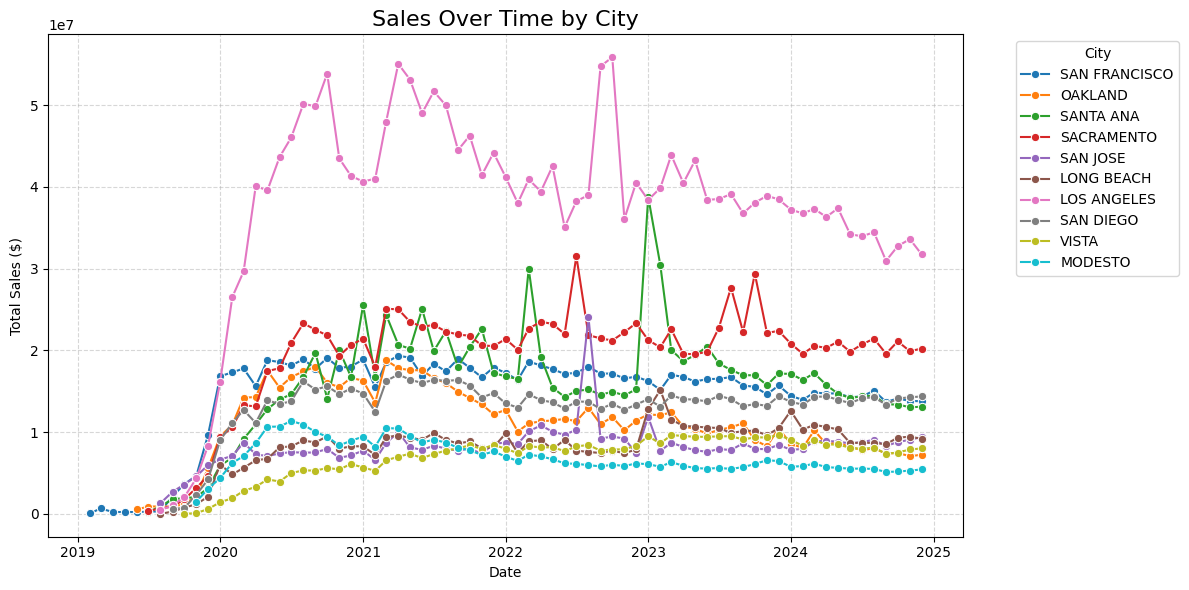

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sales_df = pd.read_stata("Data/Working_data/sales_w_parent_co_test.dta")

sales_df["totalsales"] = pd.to_numeric(sales_df["totalsales"], errors="coerce")

sales_df["date"] = pd.to_datetime(sales_df["date"], errors="coerce")

sales_df = sales_df.dropna(subset=["totalsales", "date"])

city_sales = (
    sales_df.groupby(["date", "retailercity"])["totalsales"]
    .sum()
    .reset_index()
)

city_sales = city_sales.sort_values(by="date")

top_cities = (
    city_sales.groupby("retailercity")["totalsales"]
    .sum()
    .nlargest(10)
    .index
)
city_sales = city_sales[city_sales["retailercity"].isin(top_cities)]

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=city_sales,
    x="date",
    y="totalsales",
    hue="retailercity",
    marker="o"
)

plt.title("Sales Over Time by City", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Total Sales ($)")
plt.legend(title="City", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [2]:
df = pd.read_excel("Data/Results/Cult_HHI__Indoor_test.xlsx")
df_mixed = pd.read_excel("Data/Results/Cult_HHI__Mixed_Light.xlsx")
df_outdoor = pd.read_excel("Data/Results/Cult_HHI__Outdoor.xlsx")
df['source_file'] = 'Indoor'
df_mixed['source_file'] = 'Mixed_Light'
df_outdoor['source_file'] = 'Outdoor'

df_combined = pd.concat([df, df_mixed, df_outdoor], ignore_index=True)
df_combined = df_combined[~df_combined.astype(str).apply(lambda x: x.str.contains("CA")).any(axis=1)]

display(df_combined.head())
print(df_combined.columns)

,premiseCounty,mkt_share2_Canopy,Canopy,mkt_share2_MaxSqFt,MaxSqFt,level,source_file
0,Alameda,187.0,885606.0,161.0,1426860,Overall,Indoor
1,Calaveras,10000.0,455.0,10000.0,500,Overall,Indoor
2,Colusa,4321.0,21224.0,5215.0,32000,Overall,Indoor
3,Contra Costa,1356.0,271103.0,1024.0,397560,Overall,Indoor
4,Del Norte,10000.0,1671.0,10000.0,5000,Overall,Indoor


Index(['premiseCounty', 'mkt_share2_Canopy', 'Canopy', 'mkt_share2_MaxSqFt',
       'MaxSqFt', 'level', 'source_file'],
      dtype='object')


C:\Users\nooro\AppData\Local\Temp\ipykernel_39720\3611284954.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='premiseCounty', y='mkt_share2_Canopy', data=subset, palette='viridis')


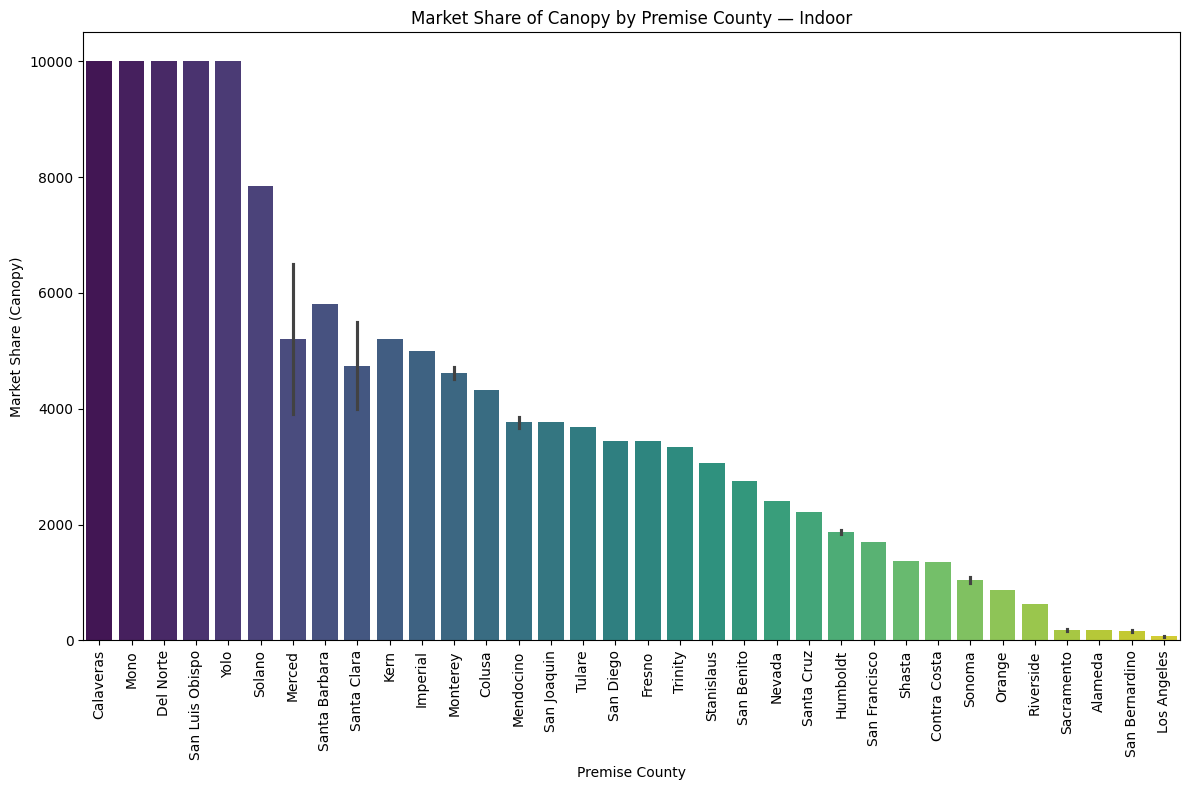

C:\Users\nooro\AppData\Local\Temp\ipykernel_39720\3611284954.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='premiseCounty', y='mkt_share2_Canopy', data=subset, palette='viridis')


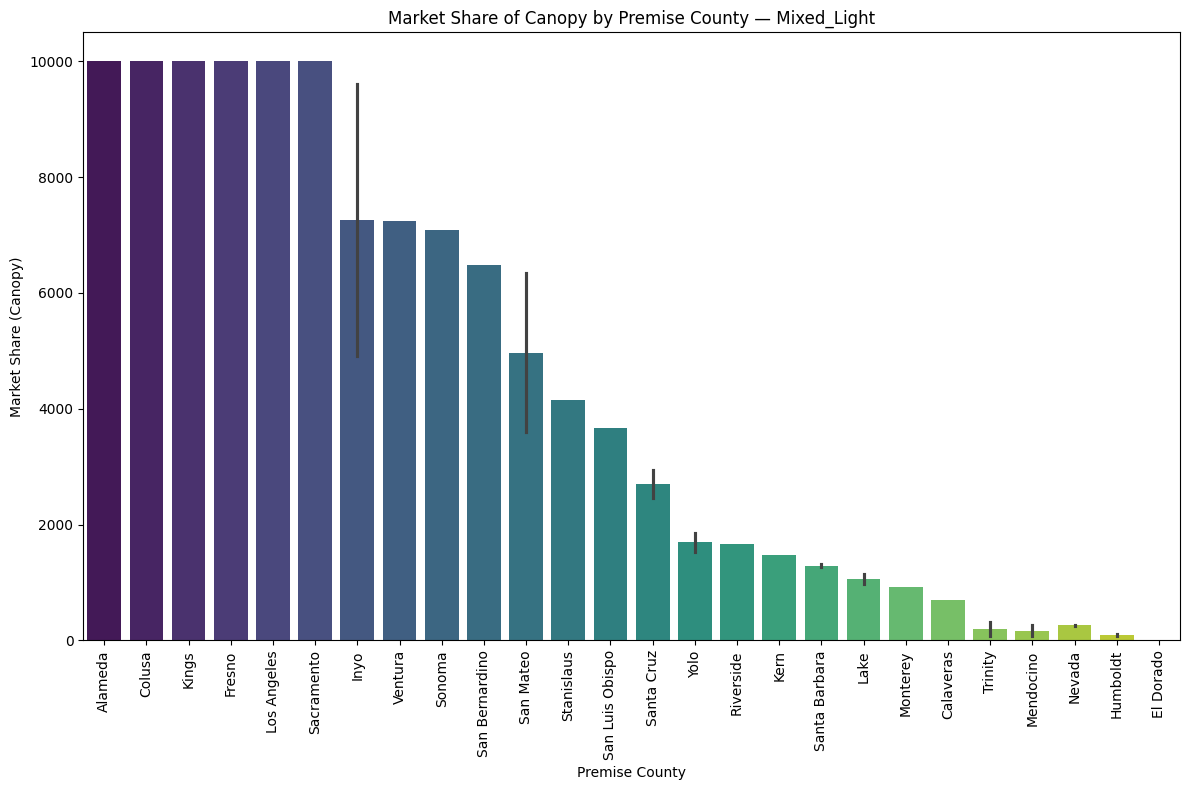

C:\Users\nooro\AppData\Local\Temp\ipykernel_39720\3611284954.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='premiseCounty', y='mkt_share2_Canopy', data=subset, palette='viridis')


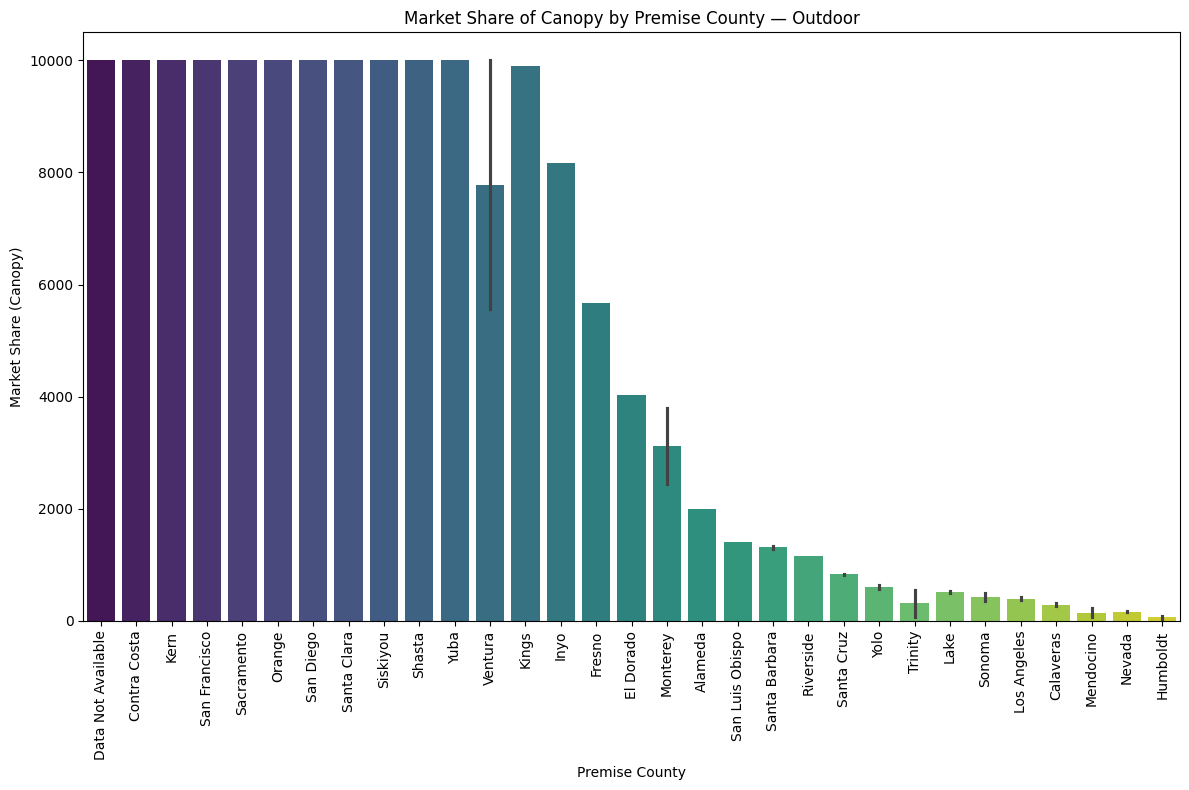

In [ ]:
for src in df_combined['source_file'].unique():
    subset = df_combined[df_combined['source_file'] == src].sort_values('mkt_share2_Canopy', ascending=False)

    plt.figure(figsize=(12, 8))
    sns.barplot(x='premiseCounty', y='mkt_share2_Canopy', data=subset, palette='viridis')
    plt.xticks(rotation=90)
    plt.xlabel('Premise County')
    plt.ylabel('Market Share (Canopy)')
    plt.title(f'Market Share of Canopy by Premise County — {src}')
    plt.tight_layout()
    plt.show()


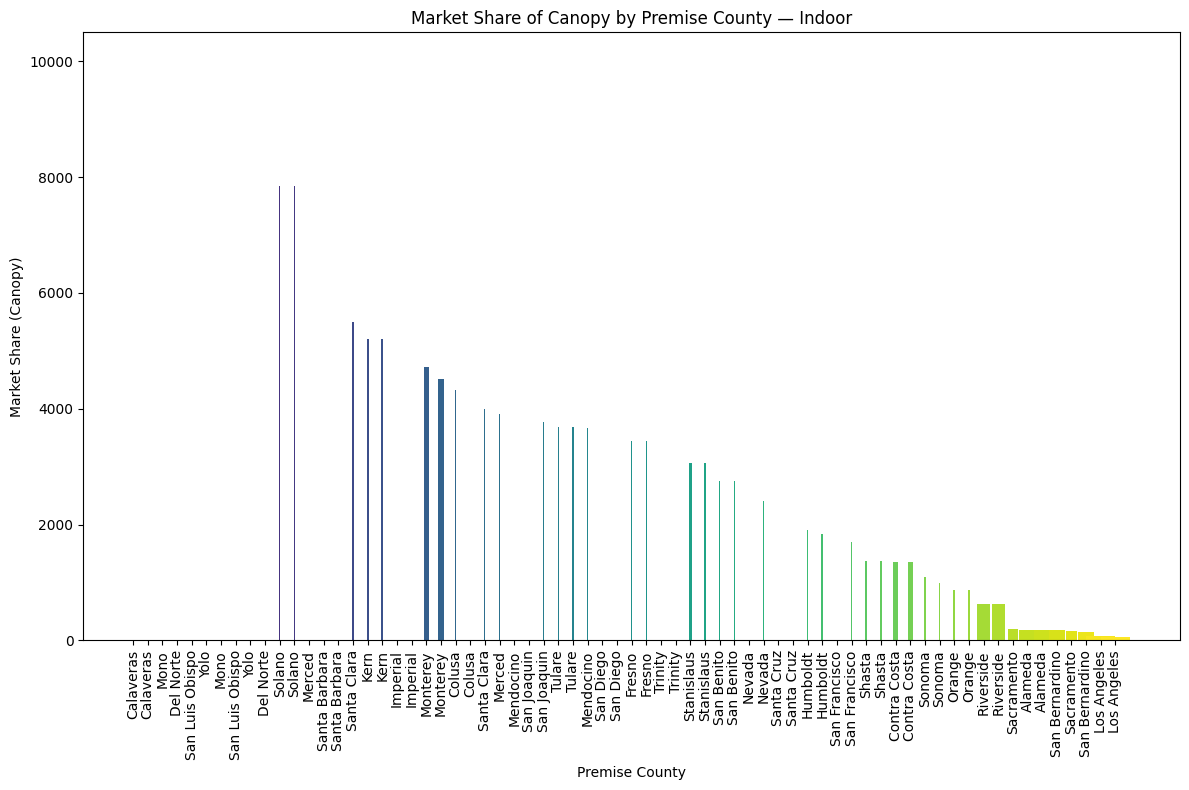

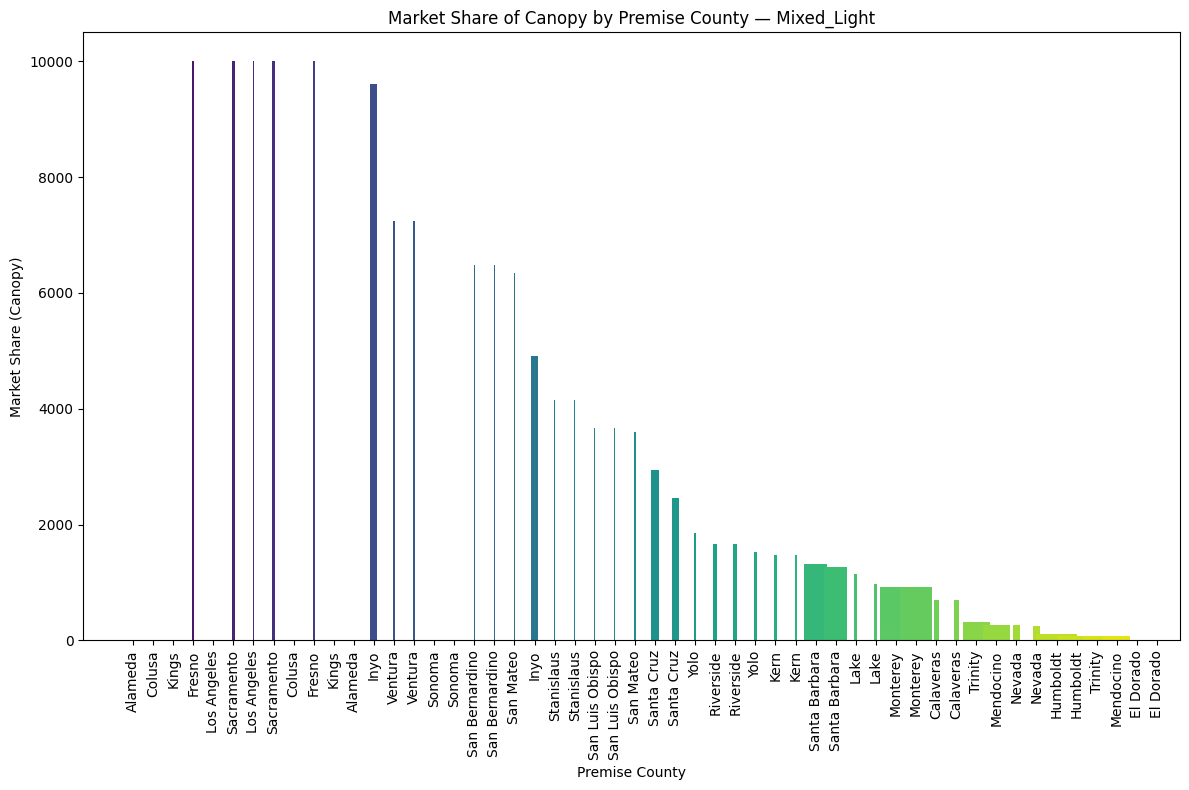

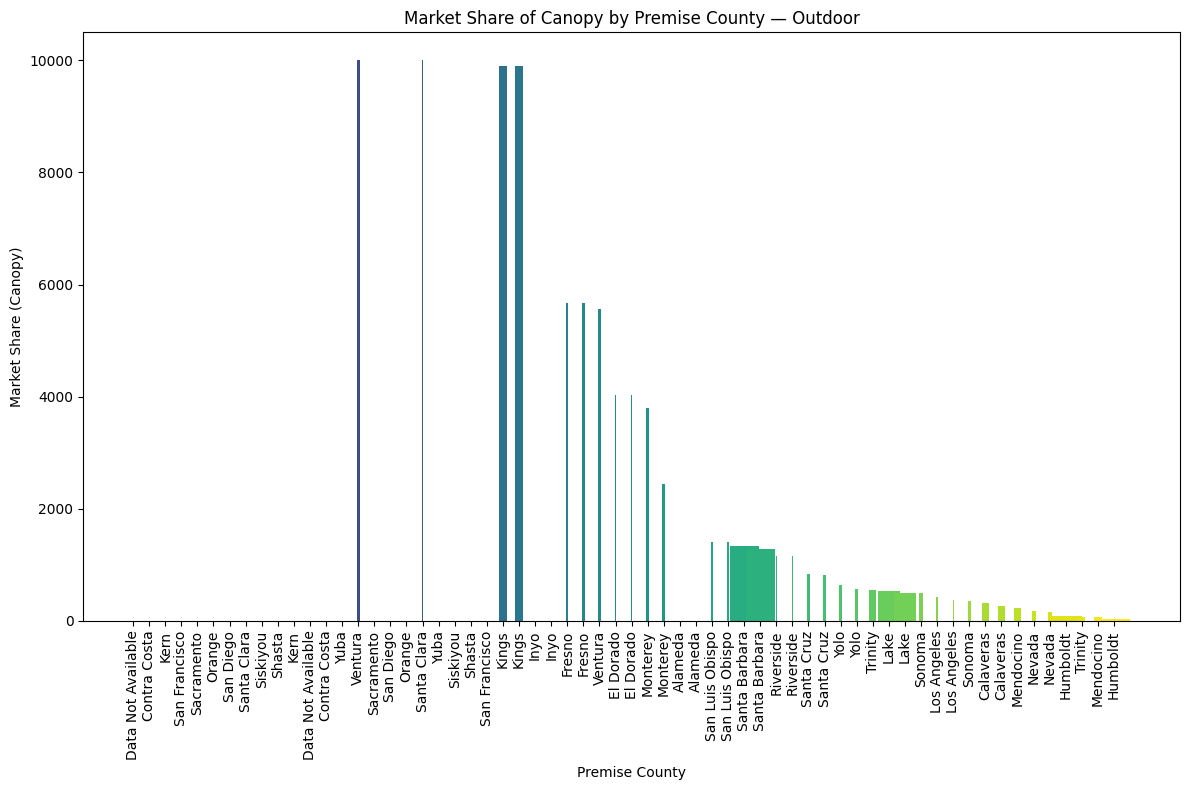

In [ ]:
for src in df_combined['source_file'].unique():
    subset = df_combined[df_combined['source_file'] == src].sort_values('mkt_share2_Canopy', ascending=False)

    # Normalize canopy (or MaxSqFt) to use as bar widths
    widths = subset['Canopy'] / subset['Canopy'].max() * 2  # scale between 0 and 20
    
    # Set positions
    x = np.arange(len(subset))

    plt.figure(figsize=(12, 8))
    plt.bar(x, subset['mkt_share2_Canopy'], width=widths, color=plt.cm.viridis(np.linspace(0, 1, len(subset))))

    plt.xticks(x, subset['premiseCounty'], rotation=90)
    plt.xlabel('Premise County')
    plt.ylabel('Market Share (Canopy)')
    plt.title(f'Market Share of Canopy by Premise County — {src}')
    plt.tight_layout()
    plt.show()

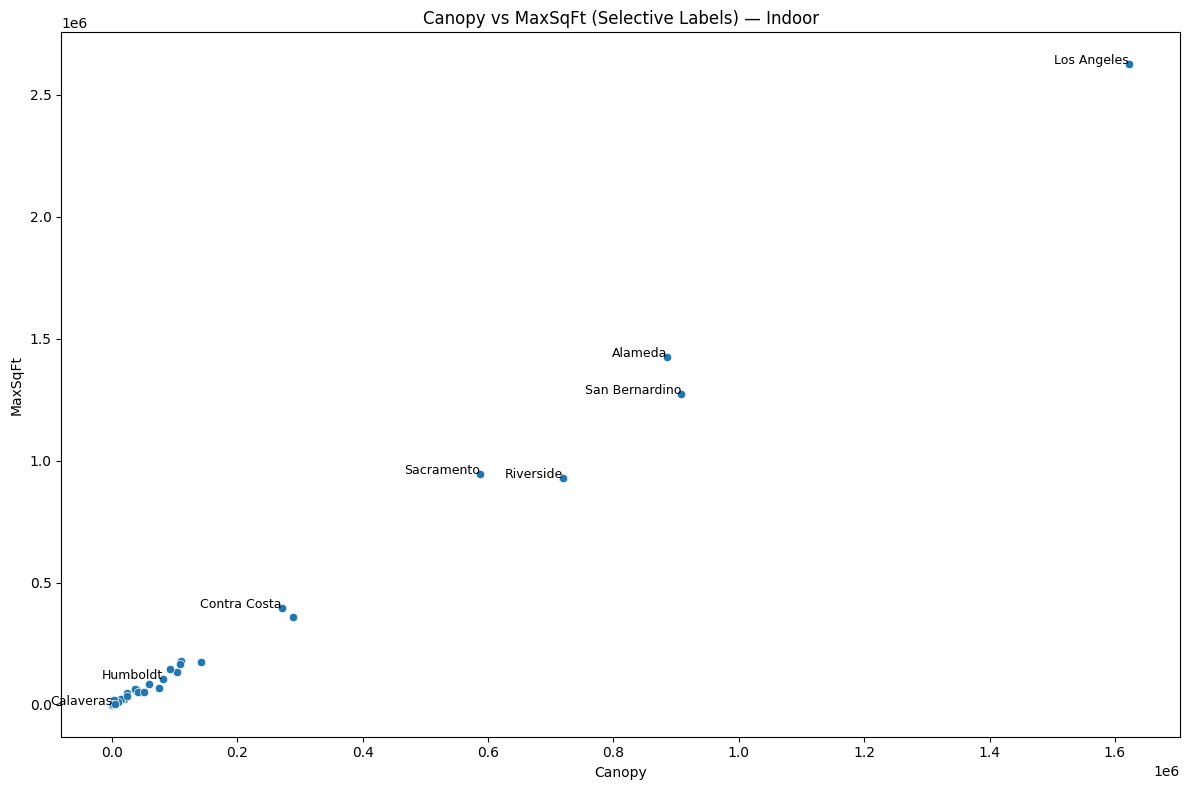

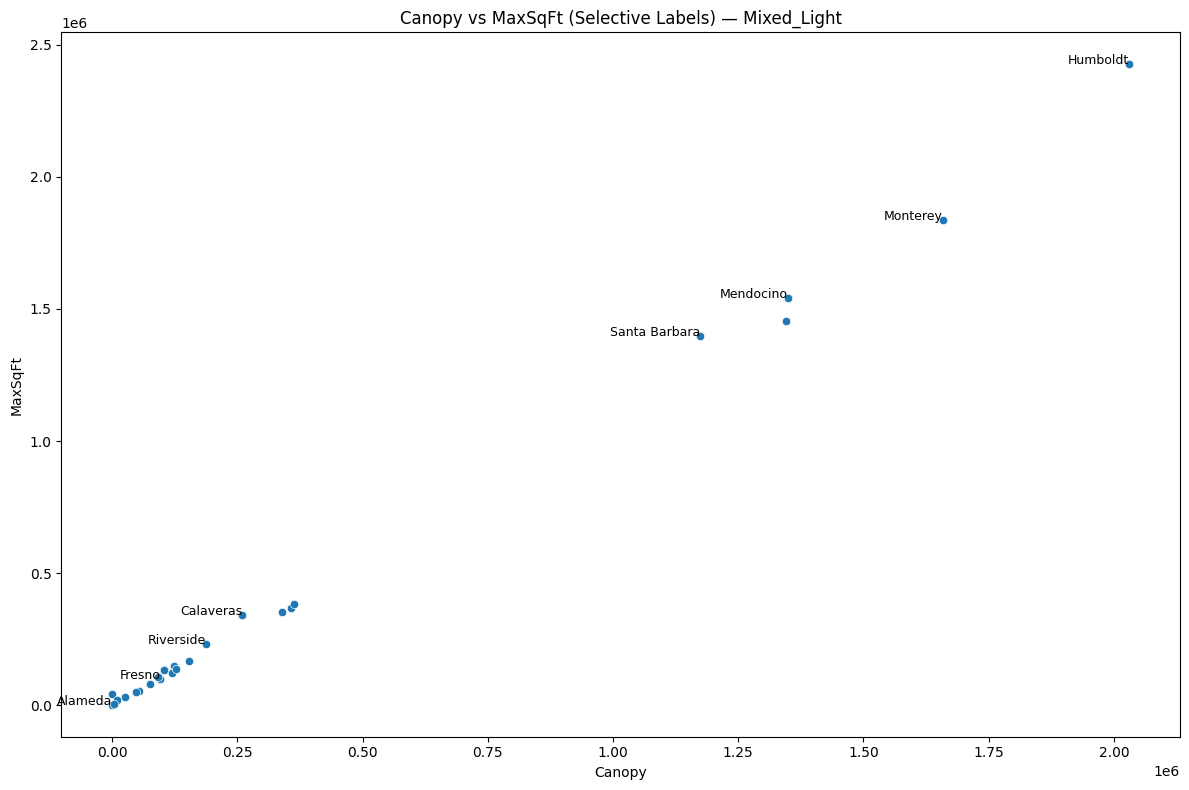

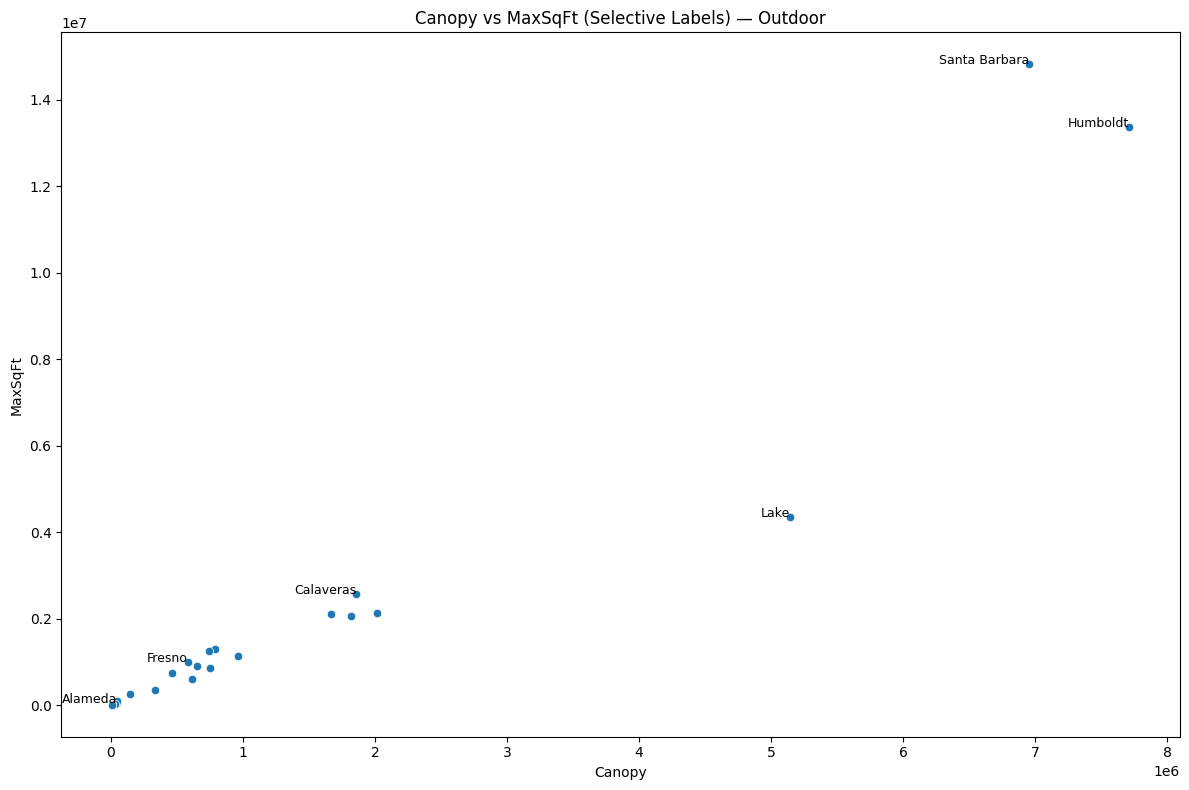

In [4]:

for src in df_combined['source_file'].unique():
    subset = df_combined[df_combined['source_file'] == src]

    plt.figure(figsize=(12, 8))
    sns.scatterplot(x='Canopy', y='MaxSqFt', data=subset)

    min_dist = 0.05 * max(subset['Canopy'].max(), subset['MaxSqFt'].max())

    labeled_points = []
    for i, row in subset.iterrows():
        x, y = row['Canopy'], row['MaxSqFt']
        # Check if this point is far from all labeled points
        if all(np.sqrt((x - lx)**2 + (y - ly)**2) > min_dist for lx, ly in labeled_points):
            plt.text(x, y, row['premiseCounty'], fontsize=9, ha='right')
            labeled_points.append((x, y))

    plt.xlabel('Canopy')
    plt.ylabel('MaxSqFt')
    plt.title(f'Canopy vs MaxSqFt (Selective Labels) — {src}')
    plt.tight_layout()
    plt.show()


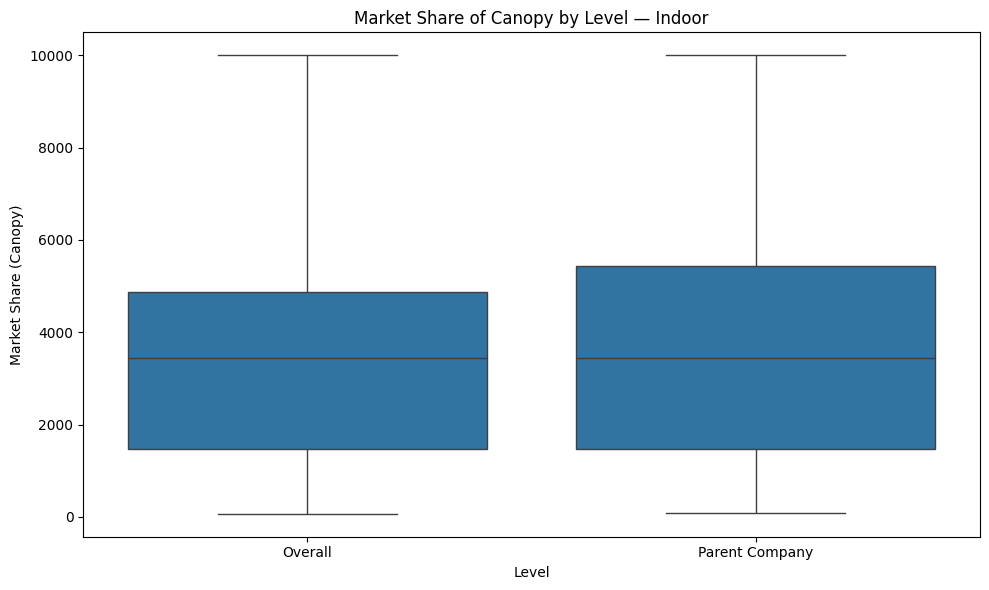

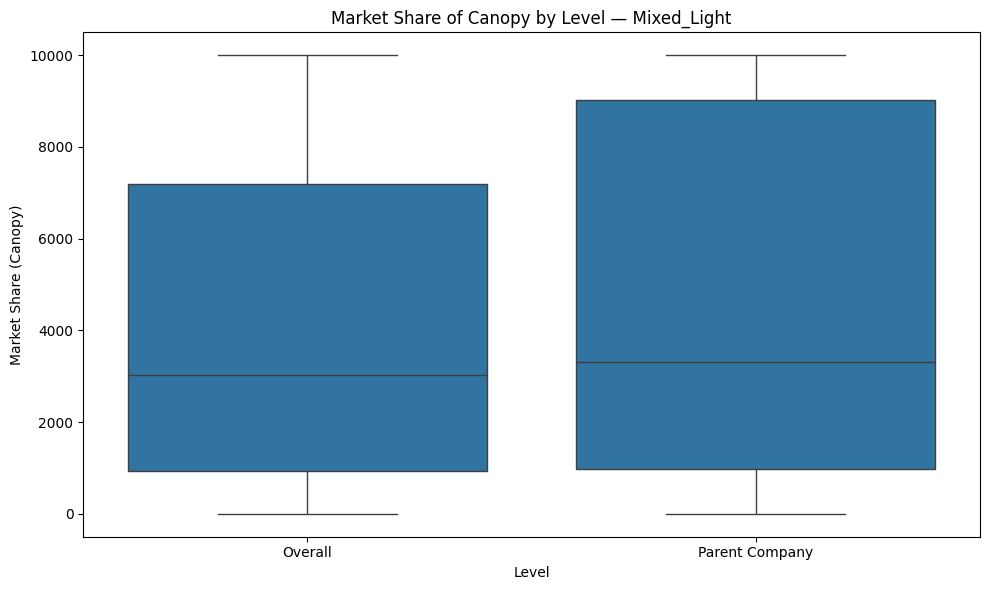

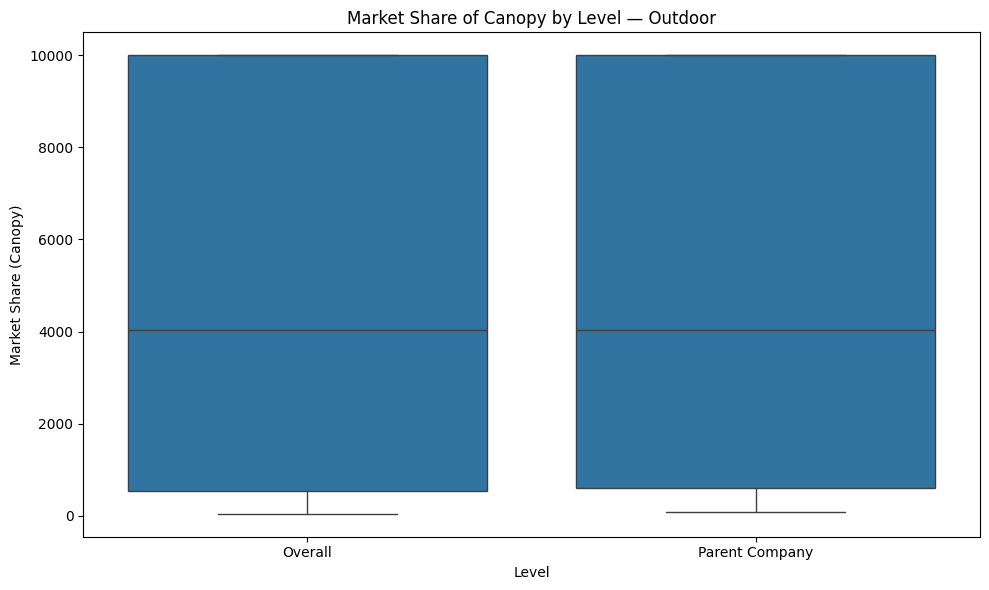

In [5]:
for src in df_combined['source_file'].unique():
    subset = df_combined[df_combined['source_file'] == src]

    plt.figure(figsize=(10, 6))
    sns.boxplot(x='level', y='mkt_share2_Canopy', data=subset)
    plt.xlabel('Level')
    plt.ylabel('Market Share (Canopy)')
    plt.title(f'Market Share of Canopy by Level — {src}')
    plt.tight_layout()
    plt.show()

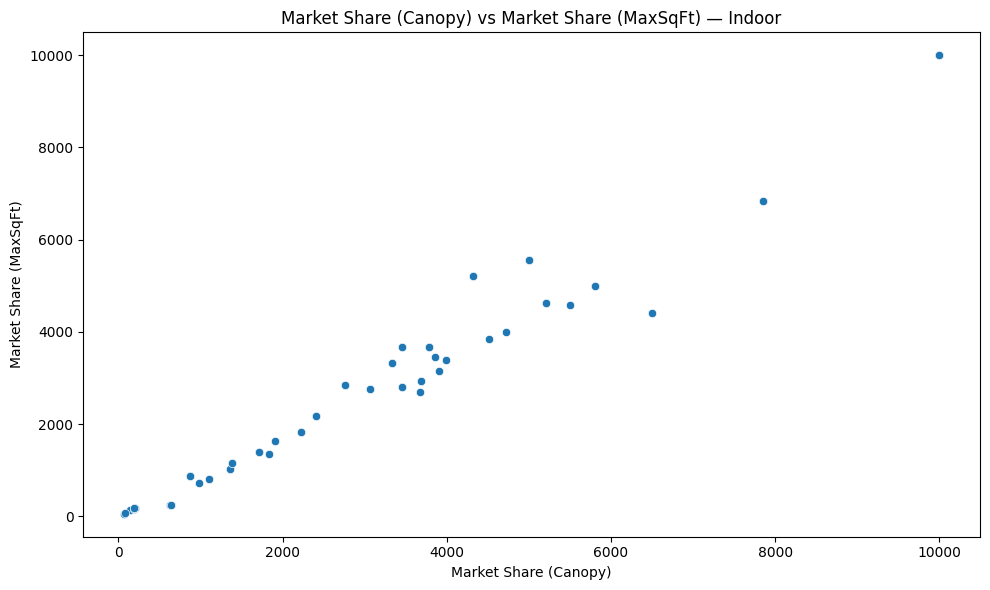

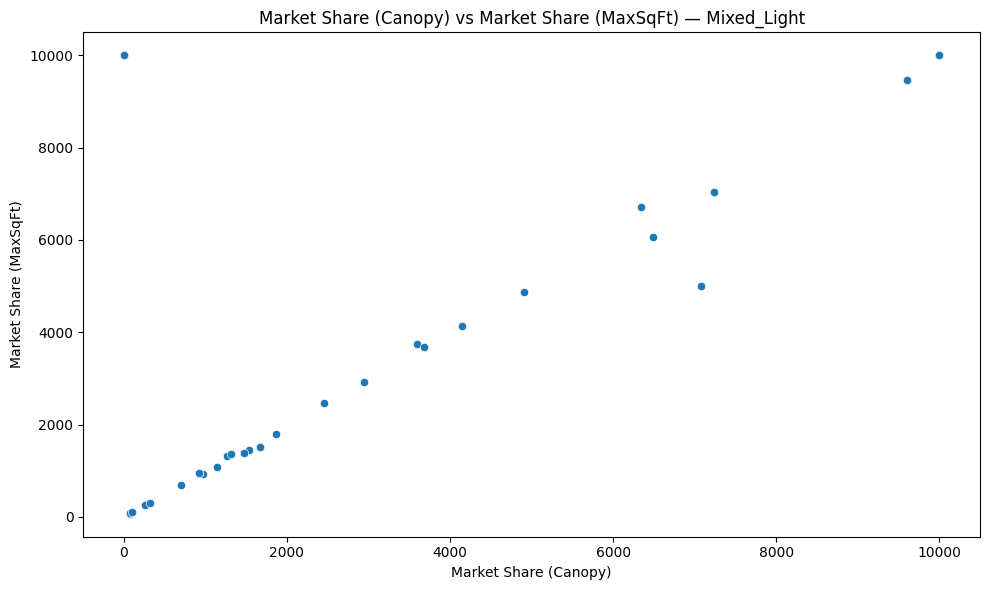

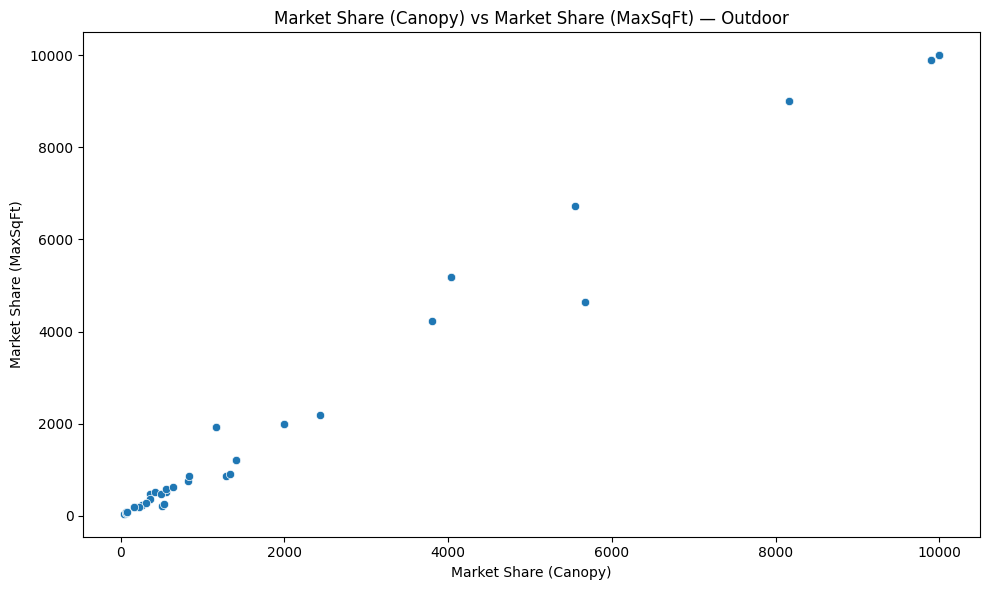

In [6]:
for src in df_combined['source_file'].unique():
    subset = df_combined[df_combined['source_file'] == src]

    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='mkt_share2_Canopy', y='mkt_share2_MaxSqFt', data=subset)
    plt.xlabel('Market Share (Canopy)')
    plt.ylabel('Market Share (MaxSqFt)')
    plt.title(f'Market Share (Canopy) vs Market Share (MaxSqFt) — {src}')
    plt.tight_layout()
    plt.show()

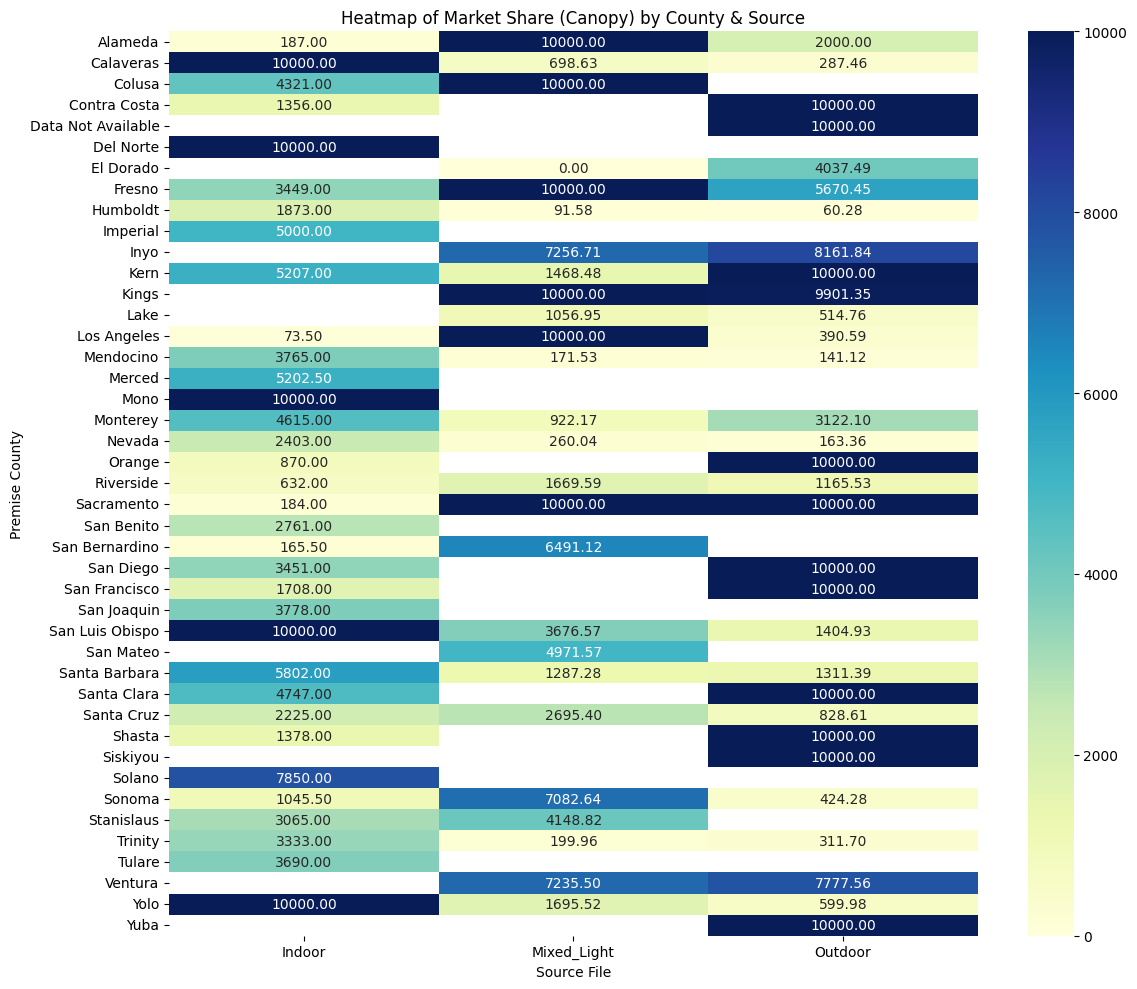

In [7]:
heatmap_df = df_combined.pivot_table(
    index='premiseCounty',
    columns='source_file',
    values='mkt_share2_Canopy'
)

plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap='YlGnBu')
plt.title('Heatmap of Market Share (Canopy) by County & Source')
plt.ylabel('Premise County')
plt.xlabel('Source File')
plt.tight_layout()
plt.show()


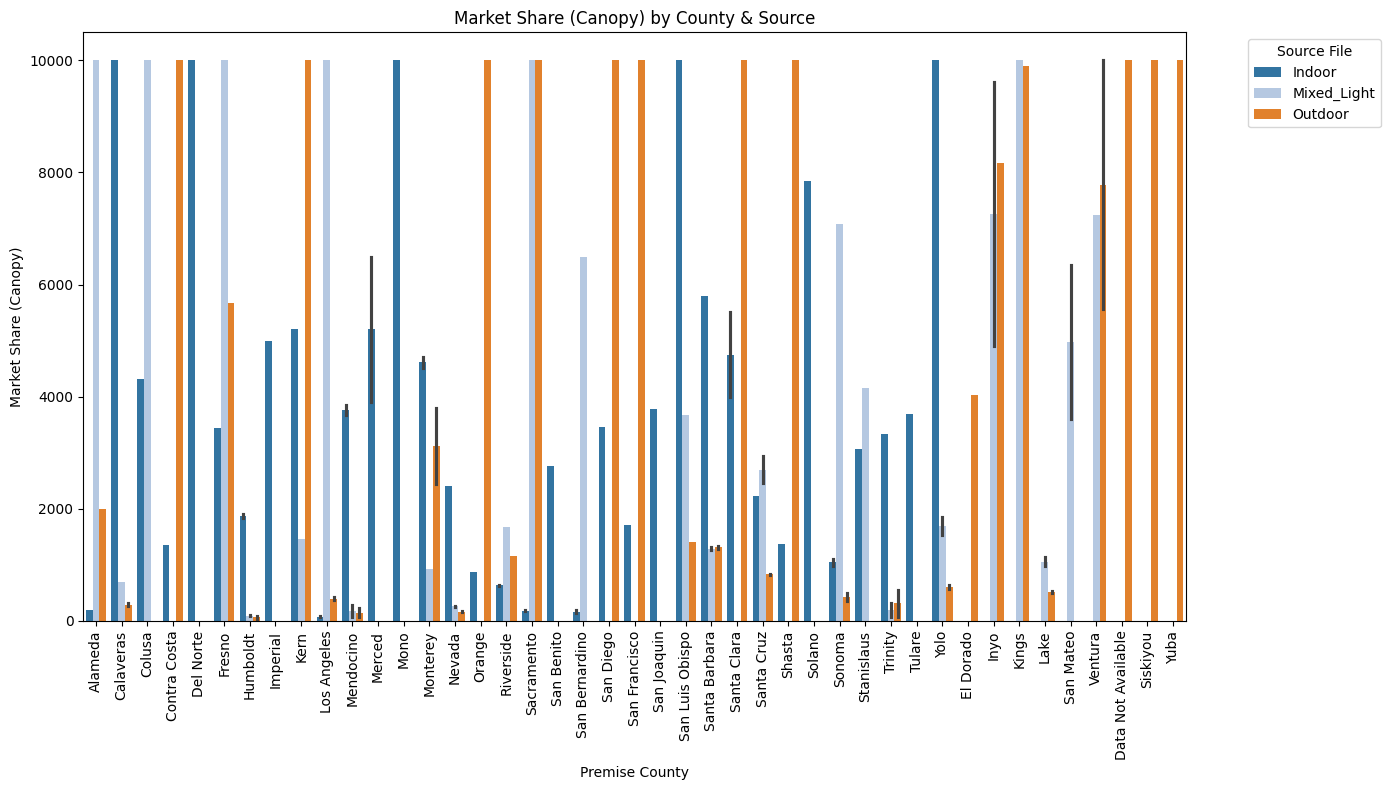

In [8]:
plt.figure(figsize=(14, 8))
sns.barplot(
    x='premiseCounty',
    y='mkt_share2_Canopy',
    hue='source_file',
    data=df_combined,
    palette='tab20'
)

plt.xticks(rotation=90)
plt.xlabel('Premise County')
plt.ylabel('Market Share (Canopy)')
plt.title('Market Share (Canopy) by County & Source')
plt.legend(title='Source File', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [9]:
df_prepared_for_viz = pd.melt(df_combined,
                              id_vars=['premiseCounty', 'source_file', 'level'],
                              value_vars=['mkt_share2_Canopy', 'mkt_share2_MaxSqFt', 'Canopy', 'MaxSqFt'],
                              var_name='metric',
                              value_name='value')

display(df_prepared_for_viz.head())

,premiseCounty,source_file,level,metric,value
0,Alameda,Indoor,Overall,mkt_share2_Canopy,187.0
1,Calaveras,Indoor,Overall,mkt_share2_Canopy,10000.0
2,Colusa,Indoor,Overall,mkt_share2_Canopy,4321.0
3,Contra Costa,Indoor,Overall,mkt_share2_Canopy,1356.0
4,Del Norte,Indoor,Overall,mkt_share2_Canopy,10000.0


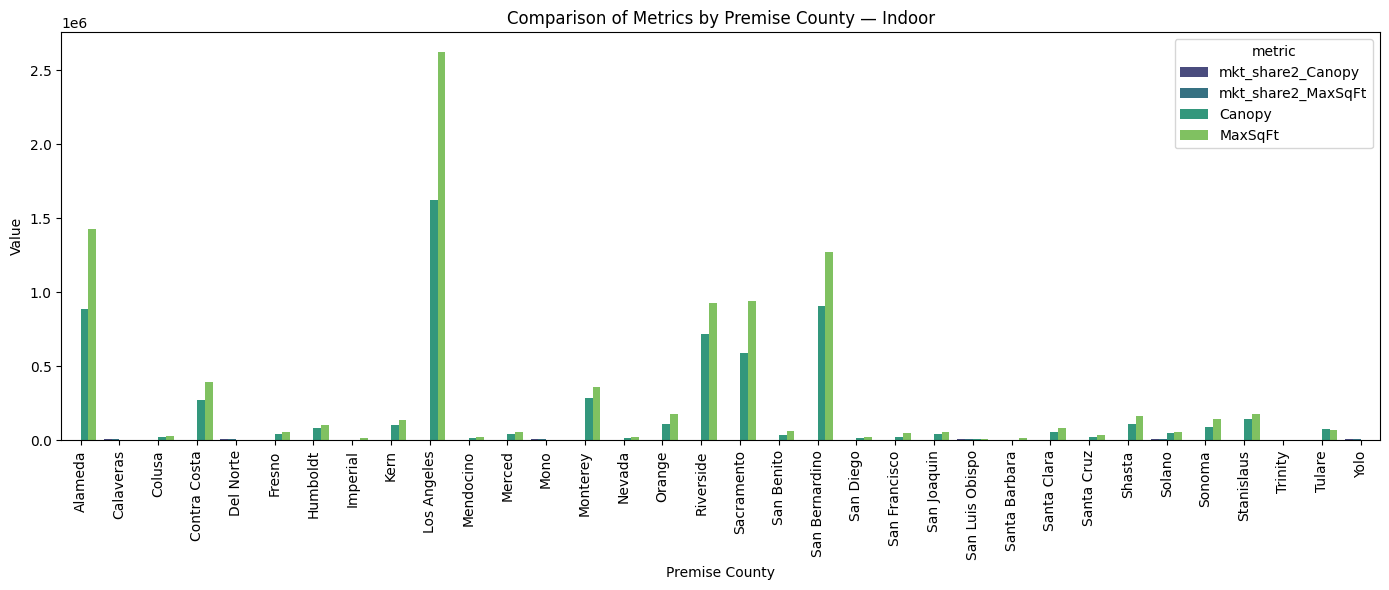

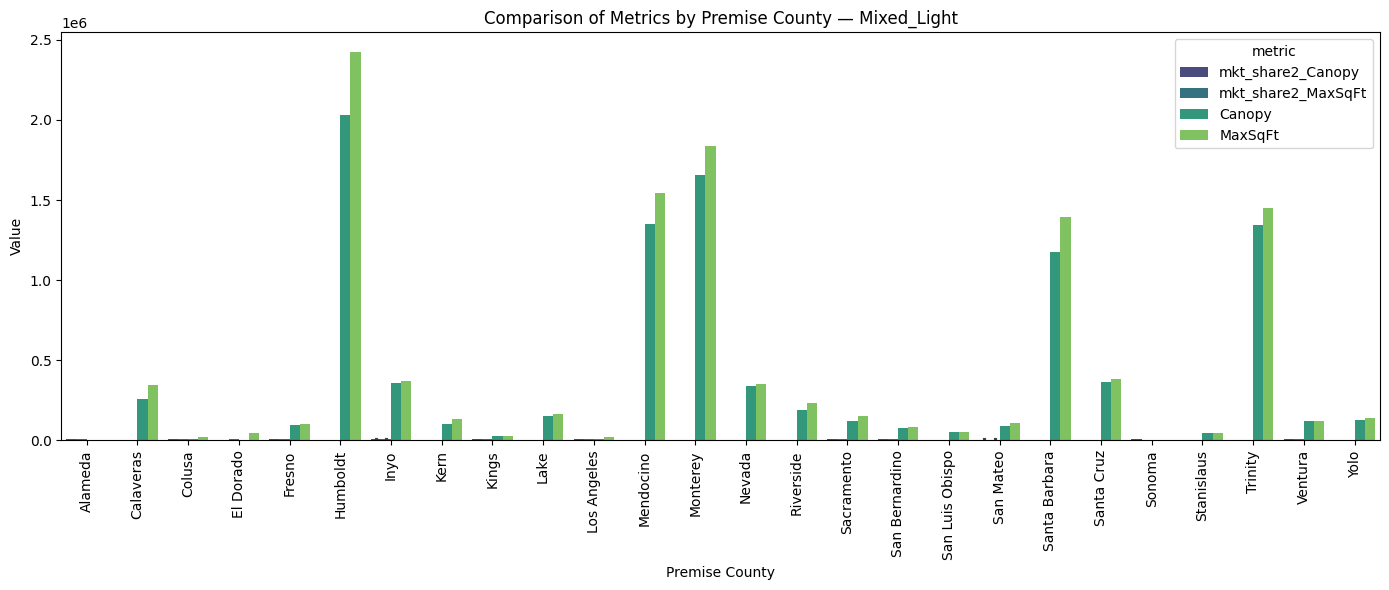

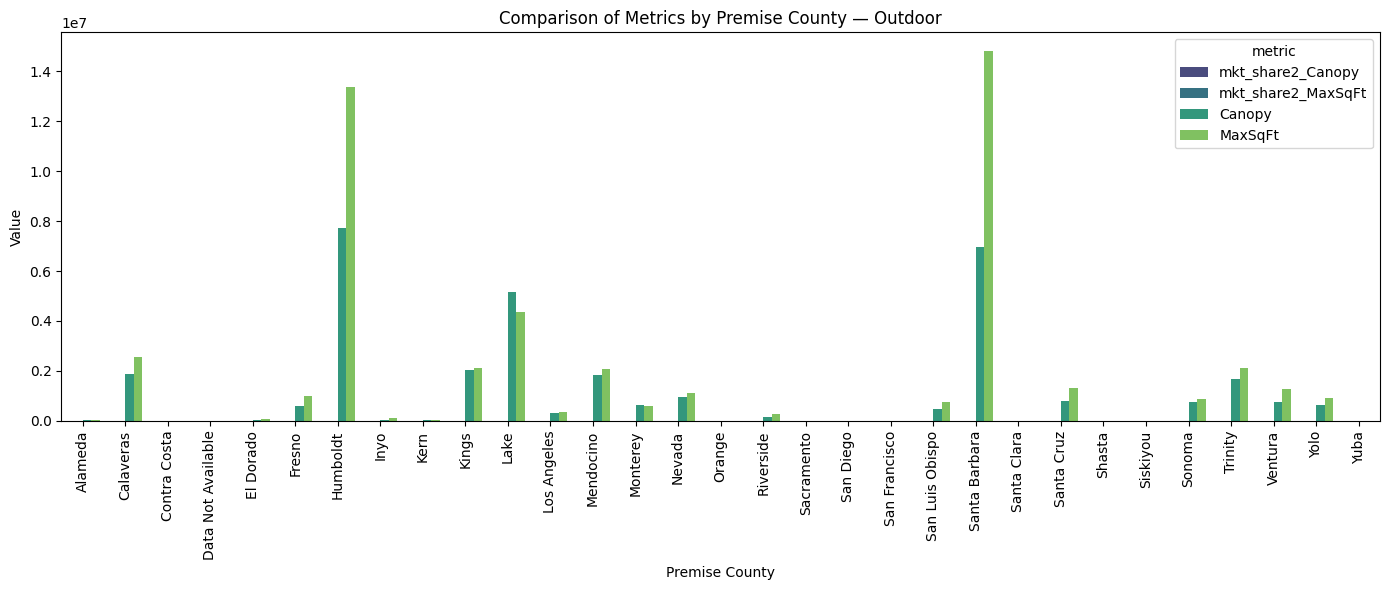

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

for src in df_prepared_for_viz['source_file'].unique():
    subset = df_prepared_for_viz[df_prepared_for_viz['source_file'] == src]
    
    plt.figure(figsize=(14, 6))
    sns.barplot(
        x='premiseCounty',
        y='value',
        hue='metric',
        data=subset,
        palette='viridis'
    )
    
    plt.xticks(rotation=90)
    plt.title(f'Comparison of Metrics by Premise County — {src}')
    plt.xlabel('Premise County')
    plt.ylabel('Value')
    plt.tight_layout()
    plt.show()


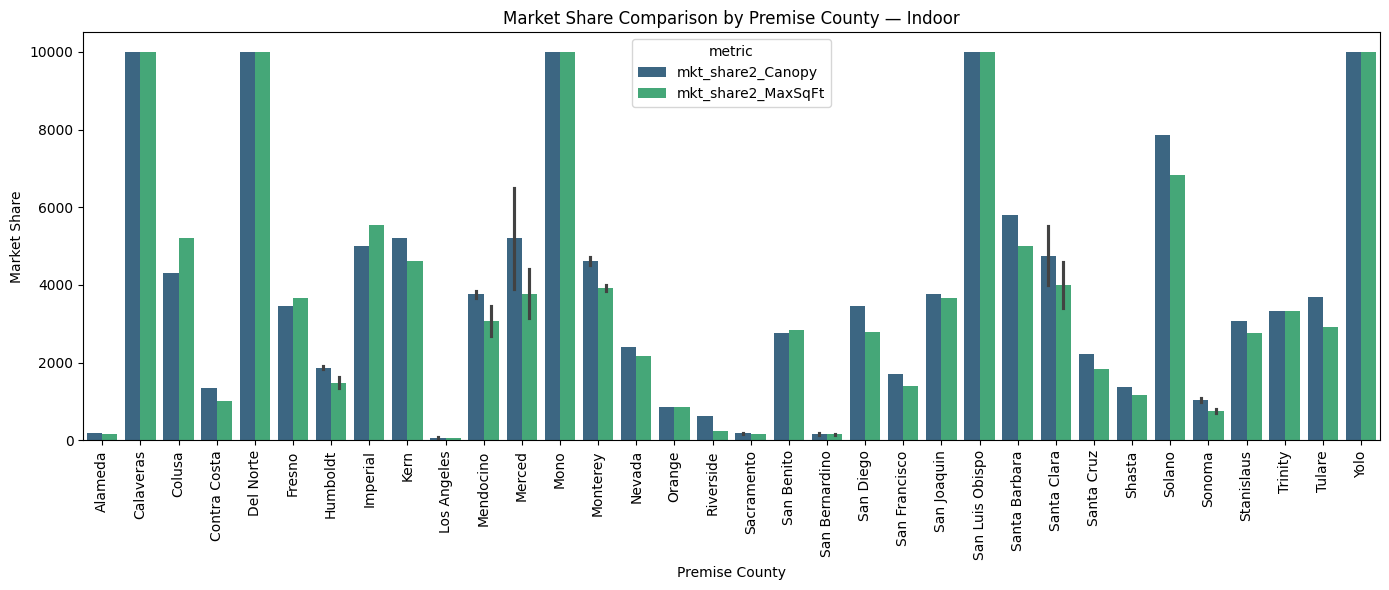

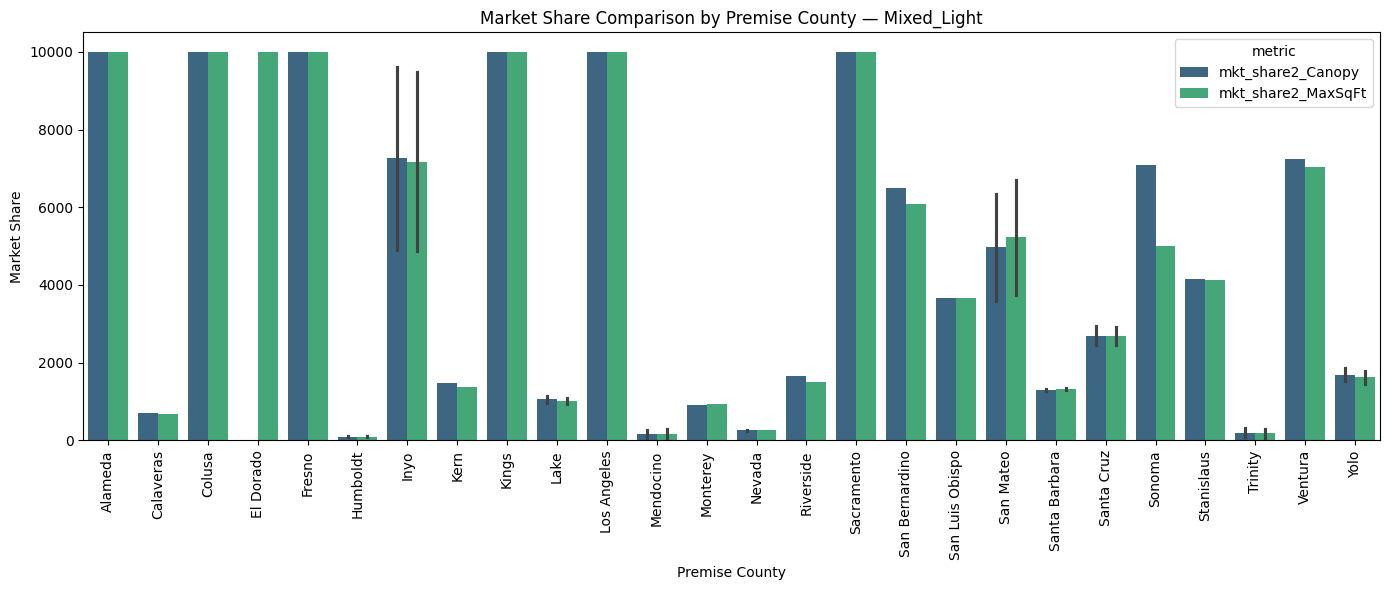

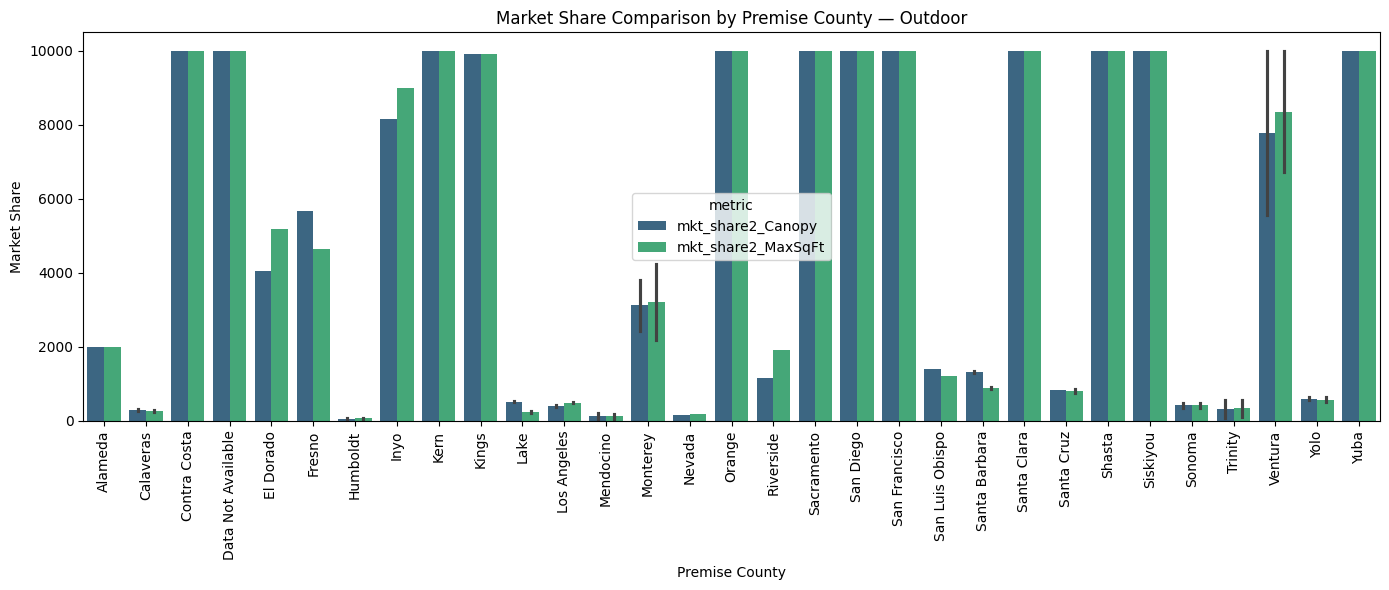

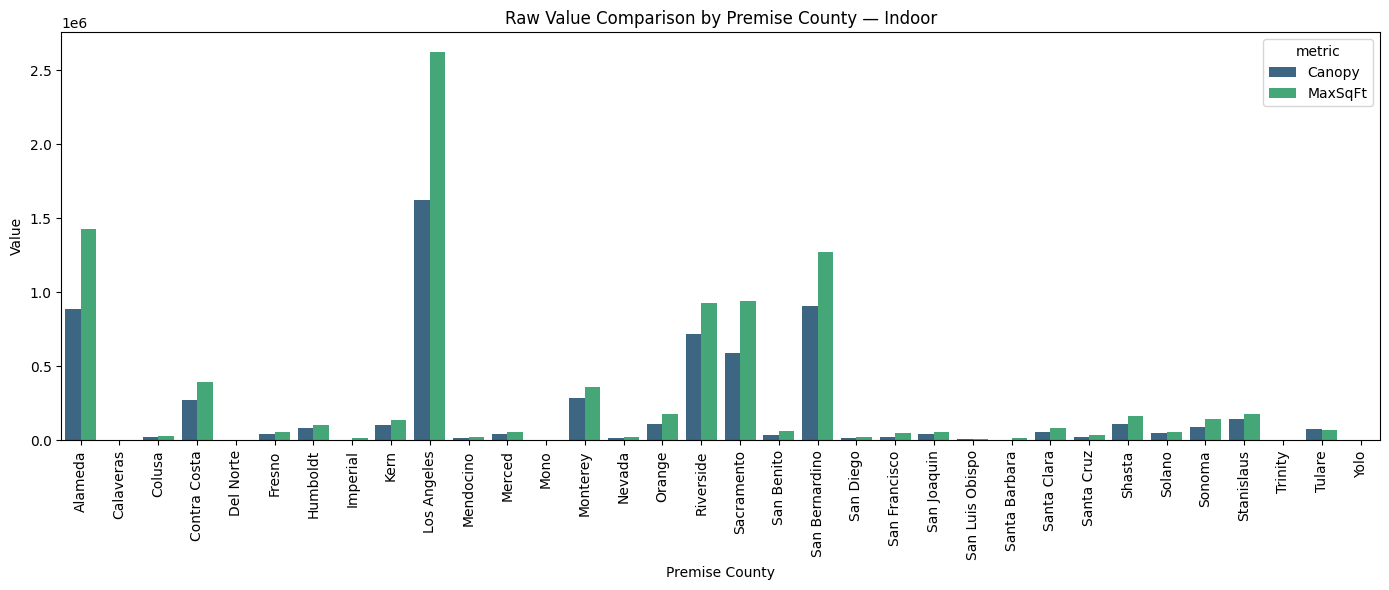

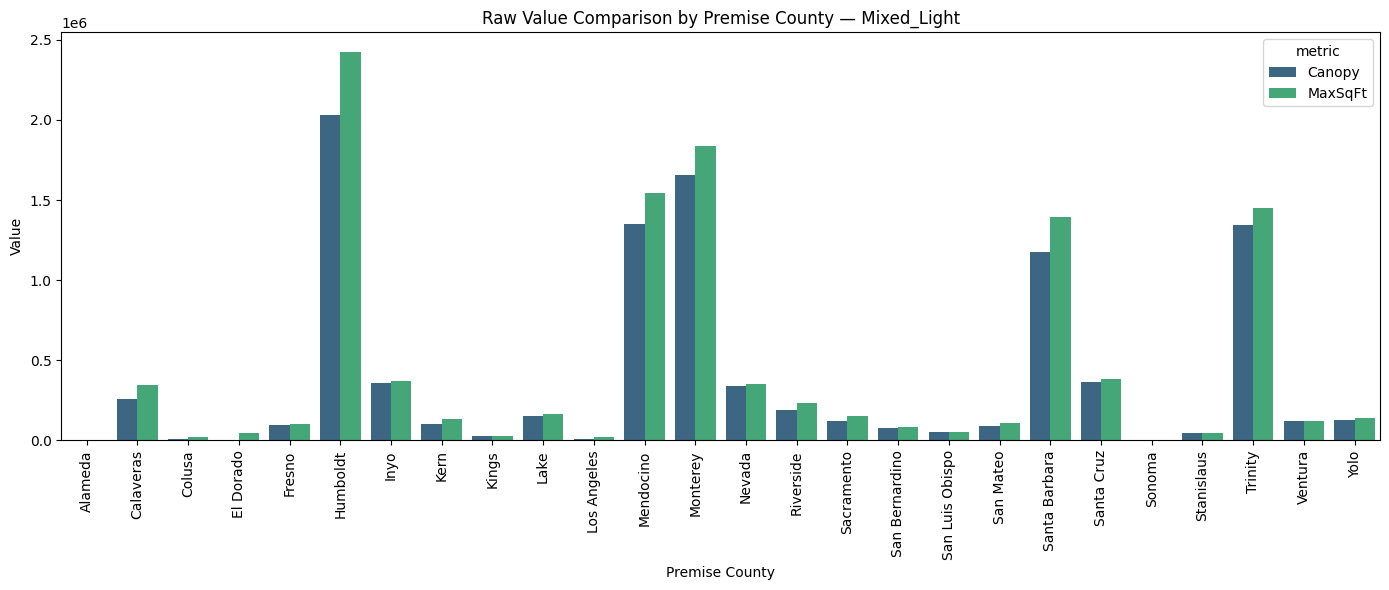

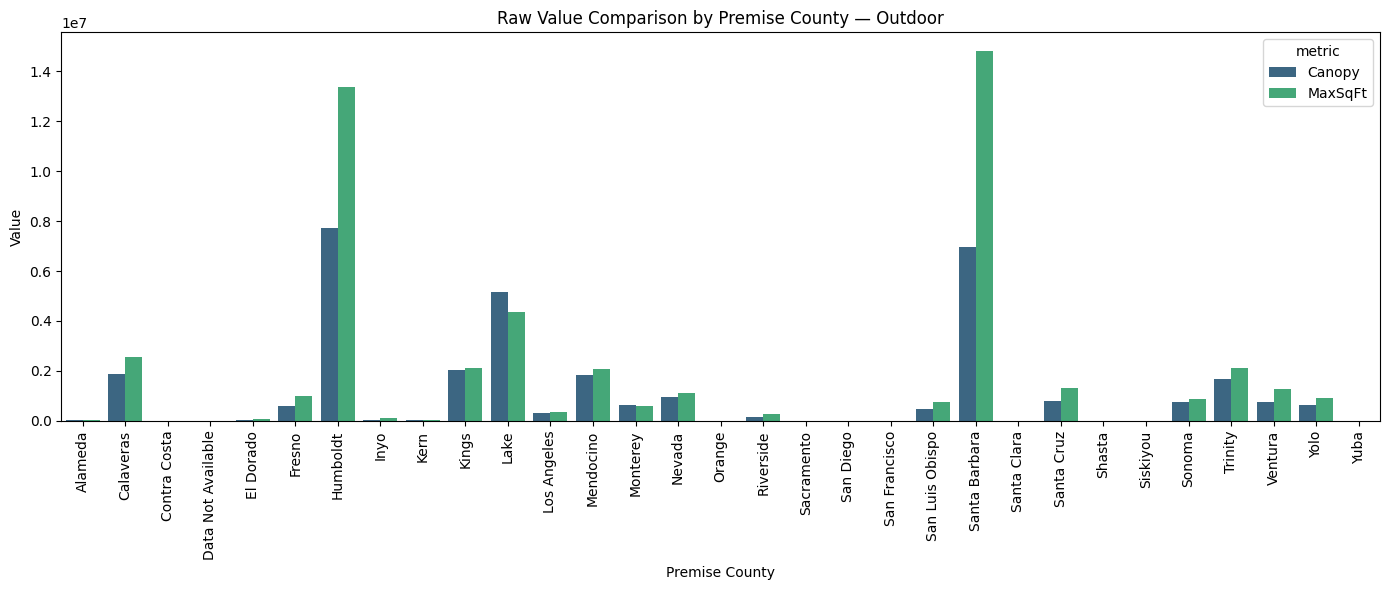

In [11]:
df_market_share = df_prepared_for_viz[
    df_prepared_for_viz['metric'].isin(['mkt_share2_Canopy', 'mkt_share2_MaxSqFt'])
]

for src in df_market_share['source_file'].unique():
    subset = df_market_share[df_market_share['source_file'] == src]
    plt.figure(figsize=(14, 6))
    sns.barplot(
        x='premiseCounty',
        y='value',
        hue='metric',
        data=subset,
        palette='viridis'
    )
    plt.xticks(rotation=90)
    plt.title(f'Market Share Comparison by Premise County — {src}')
    plt.xlabel('Premise County')
    plt.ylabel('Market Share')
    plt.tight_layout()
    plt.show()

df_raw_values = df_prepared_for_viz[
    df_prepared_for_viz['metric'].isin(['Canopy', 'MaxSqFt'])
]

for src in df_raw_values['source_file'].unique():
    subset = df_raw_values[df_raw_values['source_file'] == src]
    plt.figure(figsize=(14, 6))
    sns.barplot(
        x='premiseCounty',
        y='value',
        hue='metric',
        data=subset,
        palette='viridis'
    )
    plt.xticks(rotation=90)
    plt.title(f'Raw Value Comparison by Premise County — {src}')
    plt.xlabel('Premise County')
    plt.ylabel('Value')
    plt.tight_layout()
    plt.show()


In [12]:
df_hhi = pd.read_excel("Data/Results/HHI_by_county.xlsx")

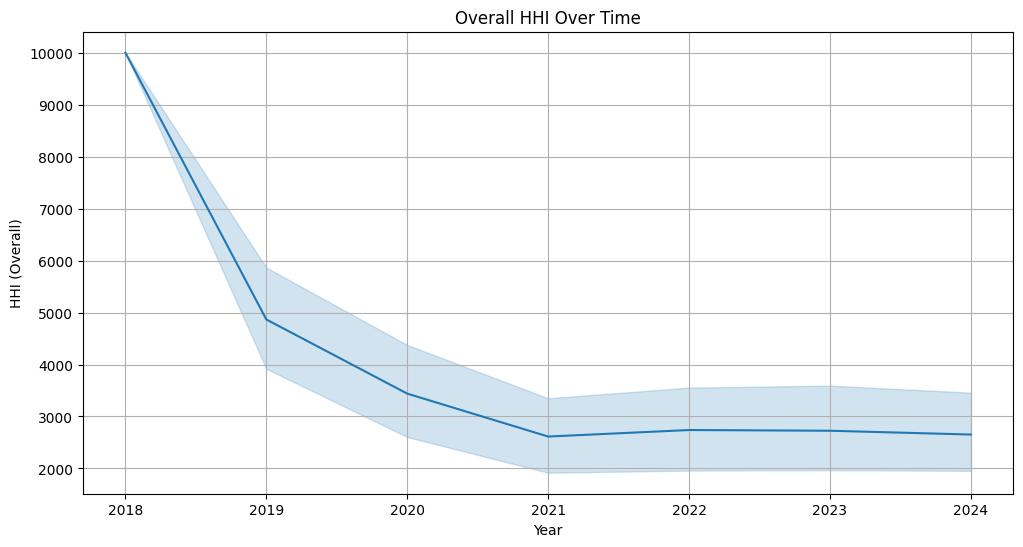

In [13]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_hhi, x='year', y='HHI')
plt.xlabel('Year')
plt.ylabel('HHI (Overall)')
plt.title('Overall HHI Over Time')
plt.grid(True)
plt.show()

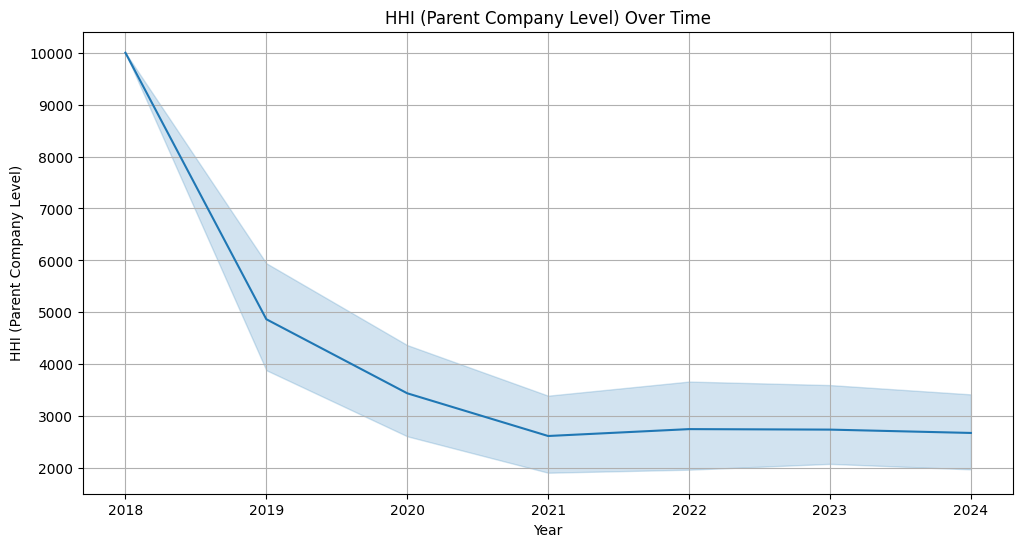

In [14]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_hhi, x='year', y='HHI_parent_level')
plt.xlabel('Year')
plt.ylabel('HHI (Parent Company Level)')
plt.title('HHI (Parent Company Level) Over Time')
plt.grid(True)
plt.show()

C:\Users\nooro\AppData\Local\Temp\ipykernel_39720\1211282545.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_latest_year, x='retailercounty', y='HHI', palette='viridis')


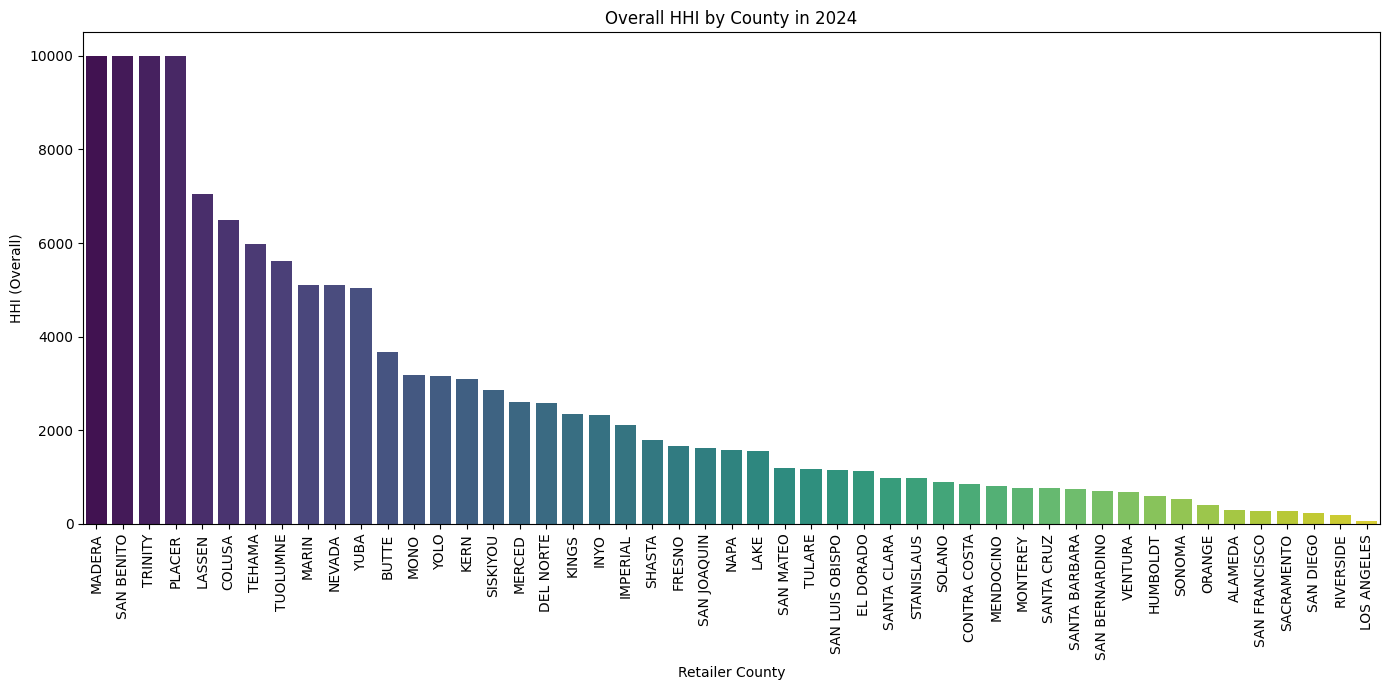

In [15]:
df_hhi_clean = df_hhi[~df_hhi.astype(str).apply(lambda x: x.str.contains("CA")).any(axis=1)]

latest_year = df_hhi_clean['year'].max()
df_latest_year = df_hhi_clean[df_hhi_clean['year'] == latest_year].sort_values('HHI', ascending=False)

plt.figure(figsize=(14, 7))
sns.barplot(data=df_latest_year, x='retailercounty', y='HHI', palette='viridis')
plt.xticks(rotation=90)
plt.xlabel('Retailer County')
plt.ylabel('HHI (Overall)')
plt.title(f'Overall HHI by County in {latest_year}')
plt.tight_layout()
plt.show()


C:\Users\nooro\AppData\Local\Temp\ipykernel_39720\460464654.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_hhi_change_sorted, x='retailercounty', y='HHI_change', palette='coolwarm')


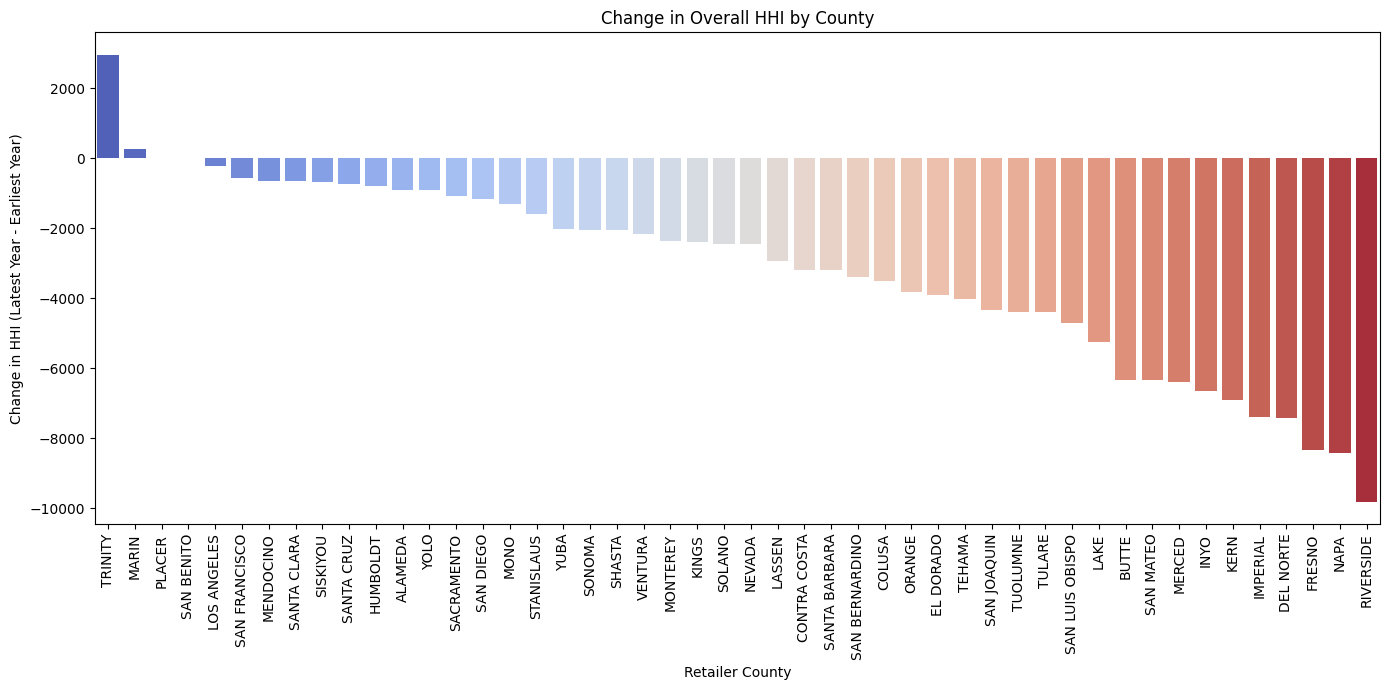

In [16]:
df_hhi_clean = df_hhi[~df_hhi.astype(str).apply(lambda x: x.str.contains("CA")).any(axis=1)]

df_hhi_change = (
    df_hhi_clean
    .groupby('retailercounty')['HHI']
    .agg(lambda x: x.iloc[-1] - x.iloc[0] if len(x) > 1 else None)
    .reset_index(name='HHI_change')
)

df_hhi_change = df_hhi_change.dropna(subset=['HHI_change'])

df_hhi_change_sorted = df_hhi_change.sort_values('HHI_change', ascending=False)

plt.figure(figsize=(14, 7))
sns.barplot(data=df_hhi_change_sorted, x='retailercounty', y='HHI_change', palette='coolwarm')
plt.xticks(rotation=90)
plt.xlabel('Retailer County')
plt.ylabel('Change in HHI (Latest Year - Earliest Year)')
plt.title('Change in Overall HHI by County')
plt.tight_layout()
plt.show()
